# A.1. PRETRAINED WEIGHTS FOR PREDICTION

In [8]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import matplotlib.pyplot as plt
from dataset import get_dataloaders
from resnet50 import ResNet50
from vgg19 import VGG19
from efficientnet import EfficientNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, class_names = get_dataloaders(
    root_dir="dataset",
    val_size=500,
    batch_size=32,
    num_workers=2
)
epochs = 20
criterion = nn.CrossEntropyLoss()
results = []
histories = {}

In [9]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, (correct / total) * 100.0

def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    total_infer_time = 0.0
    dummy = torch.randn(1, 3, 224, 224, device=device)
    with torch.no_grad():
        for _ in range(5):
            _ = model(dummy)
    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.synchronize()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if torch.cuda.is_available() and device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            outputs = model(images)
            if torch.cuda.is_available() and device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            total_infer_time += (t1 - t0)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_infer_ms = (total_infer_time / total) * 1000.0 if total > 0 else 0.0
    accuracy = (correct / total) * 100.0 if total > 0 else 0.0
    return total_loss / total, accuracy, avg_infer_ms

def visualize_predictions(model, loader, class_names, device, num_images=20):
    model.eval()
    images_shown = 0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    fig = plt.figure(figsize=(15, 12))
    with torch.no_grad():
        for images, labels in loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            preds = torch.argmax(outputs, dim=1).cpu()
            for i in range(images.size(0)):
                if images_shown >= num_images:
                    break
                img = images[i].permute(1, 2, 0).numpy()
                img = np.clip(std * img + mean, 0, 1)
                true_lbl = class_names[labels[i].item()]
                pred_lbl = class_names[preds[i].item()]
                color = "green" if true_lbl == pred_lbl else "red"
                ax = fig.add_subplot(4, 5, images_shown + 1)
                ax.imshow(img)
                ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=10)
                ax.axis("off")
                images_shown += 1
            if images_shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

# Mô hình ResNet-50

ResNet50 | Epoch 01/20 | Train Loss: 0.4153 Acc: 88.40% | Val Loss: 0.1400 Acc: 98.60%
ResNet50 | Epoch 02/20 | Train Loss: 0.1942 Acc: 93.68% | Val Loss: 0.0947 Acc: 98.80%
ResNet50 | Epoch 03/20 | Train Loss: 0.1612 Acc: 94.52% | Val Loss: 0.0636 Acc: 99.40%
ResNet50 | Epoch 04/20 | Train Loss: 0.1469 Acc: 94.36% | Val Loss: 0.0652 Acc: 99.40%
ResNet50 | Epoch 05/20 | Train Loss: 0.1307 Acc: 95.64% | Val Loss: 0.0485 Acc: 99.20%
ResNet50 | Epoch 06/20 | Train Loss: 0.1278 Acc: 95.36% | Val Loss: 0.0475 Acc: 99.40%
ResNet50 | Epoch 07/20 | Train Loss: 0.1218 Acc: 95.88% | Val Loss: 0.0412 Acc: 99.00%
ResNet50 | Epoch 08/20 | Train Loss: 0.1068 Acc: 96.00% | Val Loss: 0.0396 Acc: 99.00%
ResNet50 | Epoch 09/20 | Train Loss: 0.1134 Acc: 95.88% | Val Loss: 0.0385 Acc: 99.20%
ResNet50 | Epoch 10/20 | Train Loss: 0.1075 Acc: 95.84% | Val Loss: 0.0344 Acc: 99.60%
ResNet50 | Epoch 11/20 | Train Loss: 0.1068 Acc: 95.76% | Val Loss: 0.0312 Acc: 99.40%
ResNet50 | Epoch 12/20 | Train Loss: 0.0989

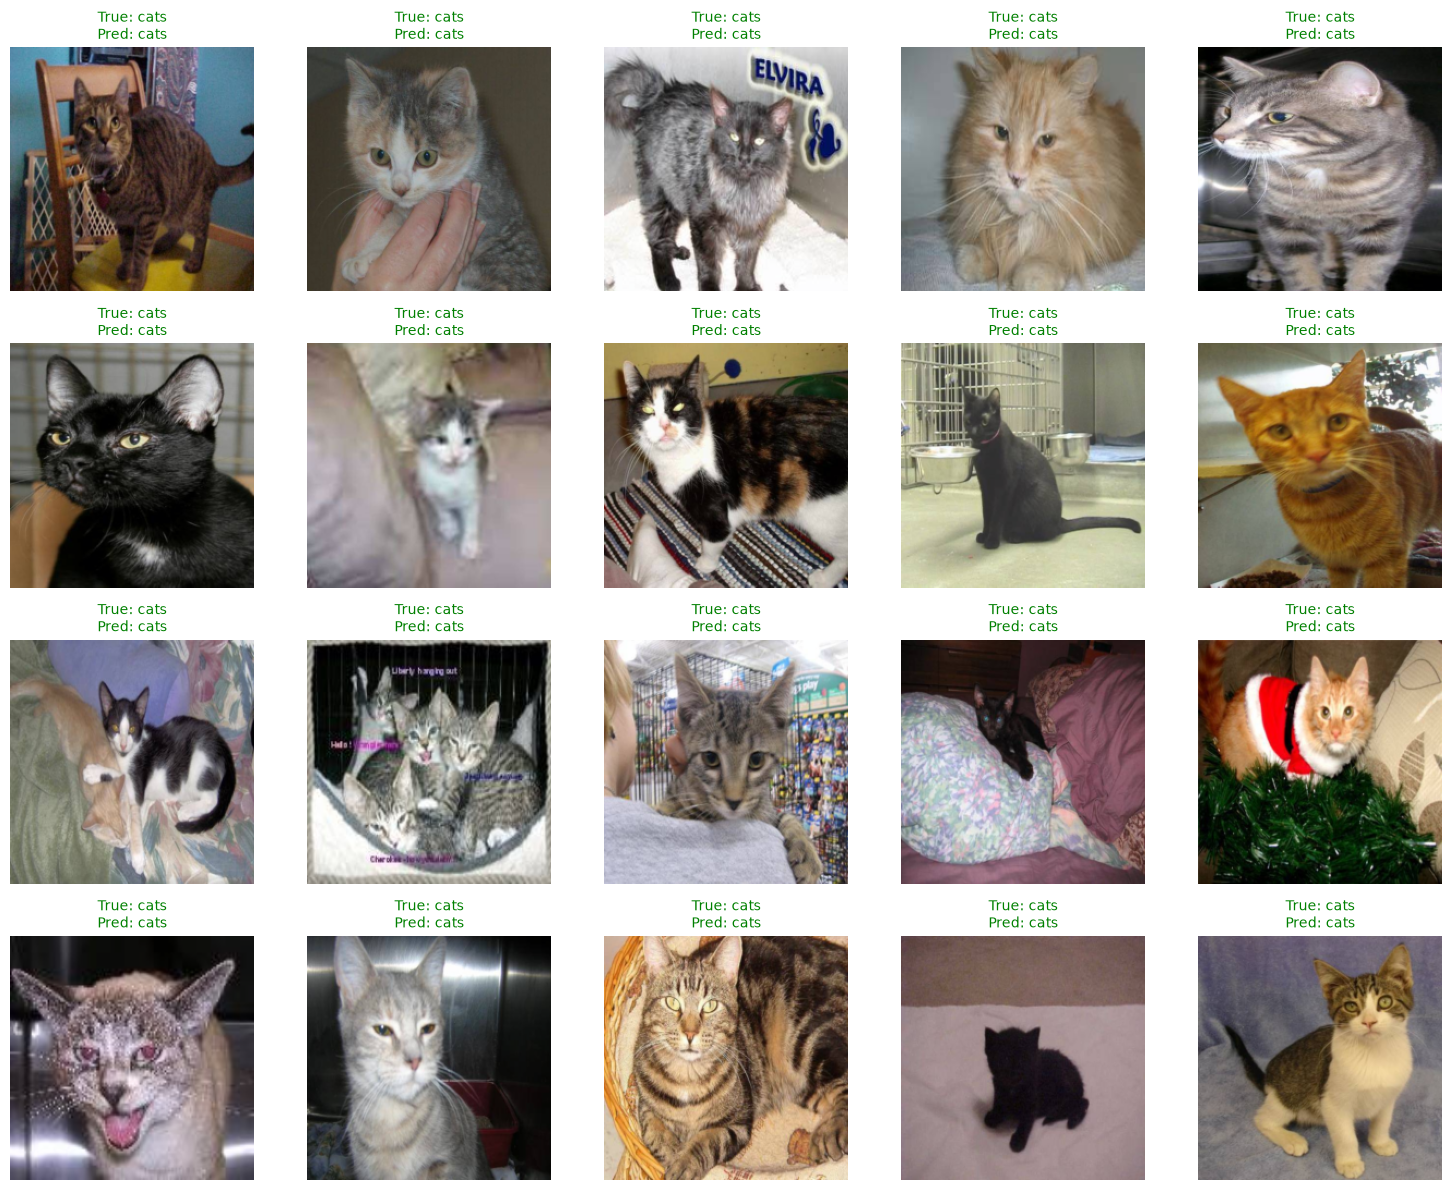

In [10]:
t0_load = time.perf_counter()
model_resnet = ResNet50(num_classes=3, pretrained=True, freeze_backbone=True)
load_time_resnet = time.perf_counter() - t0_load
model_resnet = model_resnet.to(device)

optimizer_resnet = AdamW(model_resnet.get_param_groups(lr_backbone=1e-4, lr_classifier=1e-3))
early_stopping_resnet = EarlyStopping(patience=3)
history_resnet = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(model_resnet, train_loader, criterion, optimizer_resnet, device)
    vl_loss, vl_acc, _ = evaluate_model(model_resnet, val_loader, criterion, device)
    history_resnet["train_loss"].append(tr_loss)
    history_resnet["train_acc"].append(tr_acc)
    history_resnet["val_loss"].append(vl_loss)
    history_resnet["val_acc"].append(vl_acc)
    print(f"ResNet50 | Epoch {epoch+1:02d}/{epochs} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}%")
    early_stopping_resnet(vl_loss, model_resnet)
    if early_stopping_resnet.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        early_stopping_resnet.restore(model_resnet)
        break

_, final_acc_resnet, infer_ms_resnet = evaluate_model(model_resnet, val_loader, criterion, device)
results.append({
    "model": "ResNet50",
    "accuracy": final_acc_resnet,
    "load_time": load_time_resnet,
    "avg_infer_ms": infer_ms_resnet
})
histories["ResNet50"] = history_resnet
visualize_predictions(model_resnet, val_loader, class_names, device, num_images=20)

# Mô hình VGG-19

VGG19 | Epoch 01/20 | Train Loss: 0.1652 Acc: 93.36% | Val Loss: 0.0362 Acc: 99.00%
VGG19 | Epoch 02/20 | Train Loss: 0.1130 Acc: 95.00% | Val Loss: 0.0273 Acc: 99.20%
VGG19 | Epoch 03/20 | Train Loss: 0.0919 Acc: 96.28% | Val Loss: 0.0259 Acc: 99.20%
VGG19 | Epoch 04/20 | Train Loss: 0.0895 Acc: 96.80% | Val Loss: 0.0249 Acc: 99.40%
VGG19 | Epoch 05/20 | Train Loss: 0.0863 Acc: 96.48% | Val Loss: 0.0208 Acc: 99.60%
VGG19 | Epoch 06/20 | Train Loss: 0.0798 Acc: 96.96% | Val Loss: 0.0190 Acc: 99.40%
VGG19 | Epoch 07/20 | Train Loss: 0.1024 Acc: 96.04% | Val Loss: 0.0220 Acc: 99.20%
VGG19 | Epoch 08/20 | Train Loss: 0.0928 Acc: 96.44% | Val Loss: 0.0174 Acc: 99.40%
VGG19 | Epoch 09/20 | Train Loss: 0.0807 Acc: 96.76% | Val Loss: 0.0239 Acc: 99.40%
VGG19 | Epoch 10/20 | Train Loss: 0.0777 Acc: 97.08% | Val Loss: 0.0147 Acc: 99.40%
VGG19 | Epoch 11/20 | Train Loss: 0.0699 Acc: 97.28% | Val Loss: 0.0167 Acc: 99.40%
VGG19 | Epoch 12/20 | Train Loss: 0.0886 Acc: 96.68% | Val Loss: 0.0196 Acc:

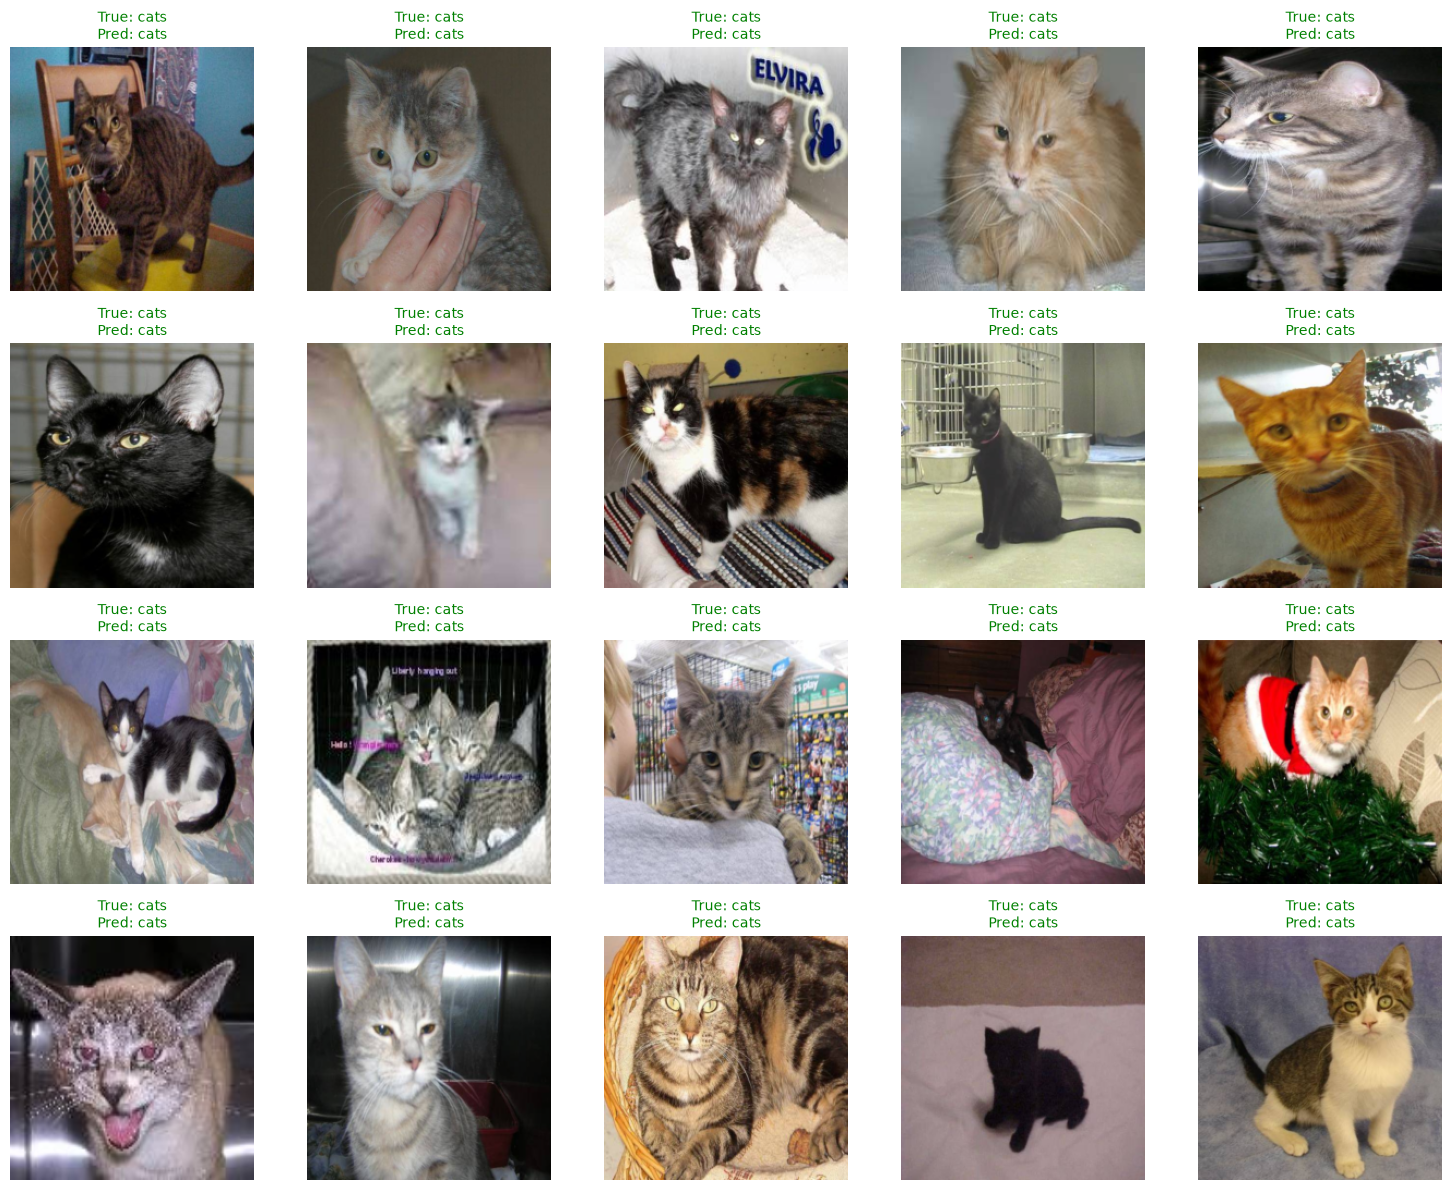

In [11]:
t0_load = time.perf_counter()
model_vgg = VGG19(num_classes=3, pretrained=True, freeze_backbone=True)
load_time_vgg = time.perf_counter() - t0_load
model_vgg = model_vgg.to(device)

optimizer_vgg = AdamW(model_vgg.get_param_groups(lr_backbone=1e-4, lr_classifier=1e-3))
early_stopping_vgg = EarlyStopping(patience=3)
history_vgg = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(model_vgg, train_loader, criterion, optimizer_vgg, device)
    vl_loss, vl_acc, _ = evaluate_model(model_vgg, val_loader, criterion, device)
    history_vgg["train_loss"].append(tr_loss)
    history_vgg["train_acc"].append(tr_acc)
    history_vgg["val_loss"].append(vl_loss)
    history_vgg["val_acc"].append(vl_acc)
    print(f"VGG19 | Epoch {epoch+1:02d}/{epochs} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}%")
    early_stopping_vgg(vl_loss, model_vgg)
    if early_stopping_vgg.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        early_stopping_vgg.restore(model_vgg)
        break

_, final_acc_vgg, infer_ms_vgg = evaluate_model(model_vgg, val_loader, criterion, device)
results.append({
    "model": "VGG19",
    "accuracy": final_acc_vgg,
    "load_time": load_time_vgg,
    "avg_infer_ms": infer_ms_vgg
})
histories["VGG19"] = history_vgg
visualize_predictions(model_vgg, val_loader, class_names, device, num_images=20)

# Mô hình EfficientNet

EfficientNet | Epoch 01/20 | Train Loss: 0.5032 Acc: 83.04% | Val Loss: 0.2081 Acc: 96.00%
EfficientNet | Epoch 02/20 | Train Loss: 0.2792 Acc: 90.48% | Val Loss: 0.1413 Acc: 97.60%
EfficientNet | Epoch 03/20 | Train Loss: 0.2406 Acc: 92.24% | Val Loss: 0.1228 Acc: 97.00%
EfficientNet | Epoch 04/20 | Train Loss: 0.2115 Acc: 92.84% | Val Loss: 0.0958 Acc: 97.60%
EfficientNet | Epoch 05/20 | Train Loss: 0.2003 Acc: 93.20% | Val Loss: 0.1034 Acc: 97.00%
EfficientNet | Epoch 06/20 | Train Loss: 0.2051 Acc: 92.56% | Val Loss: 0.0980 Acc: 97.40%
EfficientNet | Epoch 07/20 | Train Loss: 0.1825 Acc: 93.08% | Val Loss: 0.0931 Acc: 97.60%
EfficientNet | Epoch 08/20 | Train Loss: 0.1835 Acc: 92.72% | Val Loss: 0.0813 Acc: 98.00%
EfficientNet | Epoch 09/20 | Train Loss: 0.1771 Acc: 93.44% | Val Loss: 0.0774 Acc: 98.20%
EfficientNet | Epoch 10/20 | Train Loss: 0.1679 Acc: 93.60% | Val Loss: 0.0783 Acc: 98.00%
EfficientNet | Epoch 11/20 | Train Loss: 0.1619 Acc: 94.32% | Val Loss: 0.0842 Acc: 97.40%

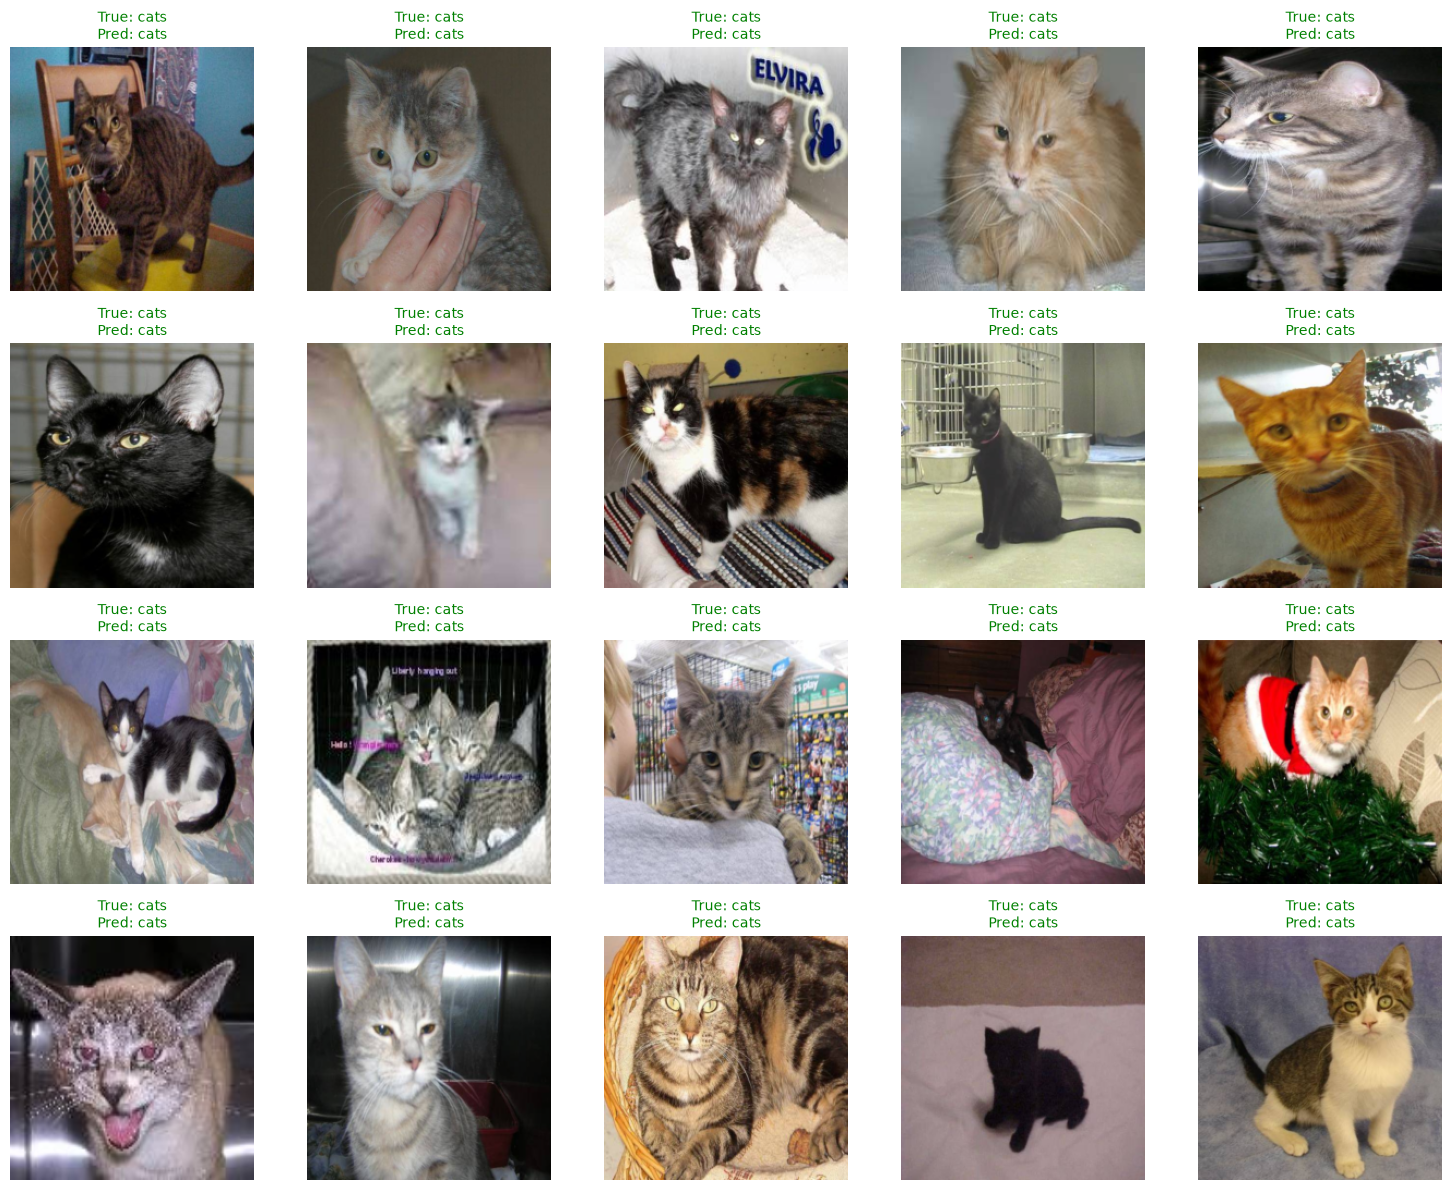

In [12]:
t0_load = time.perf_counter()
model_eff = EfficientNet(num_classes=3, pretrained=True, freeze_backbone=True)
load_time_eff = time.perf_counter() - t0_load
model_eff = model_eff.to(device)

optimizer_eff = AdamW(model_eff.get_param_groups(lr_backbone=1e-4, lr_classifier=1e-3))
early_stopping_eff = EarlyStopping(patience=3)
history_eff = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(model_eff, train_loader, criterion, optimizer_eff, device)
    vl_loss, vl_acc, _ = evaluate_model(model_eff, val_loader, criterion, device)
    history_eff["train_loss"].append(tr_loss)
    history_eff["train_acc"].append(tr_acc)
    history_eff["val_loss"].append(vl_loss)
    history_eff["val_acc"].append(vl_acc)
    print(f"EfficientNet | Epoch {epoch+1:02d}/{epochs} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}%")
    early_stopping_eff(vl_loss, model_eff)
    if early_stopping_eff.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        early_stopping_eff.restore(model_eff)
        break

_, final_acc_eff, infer_ms_eff = evaluate_model(model_eff, val_loader, criterion, device)
results.append({
    "model": "EfficientNet",
    "accuracy": final_acc_eff,
    "load_time": load_time_eff,
    "avg_infer_ms": infer_ms_eff
})
histories["EfficientNet"] = history_eff
visualize_predictions(model_eff, val_loader, class_names, device, num_images=20)

# So sánh kết quả và Trực quan hóa

In [13]:
print("-" * 80)
print(f"{'Model':<16} {'Accuracy (%)':<15} {'Load Time (s)':<18} {'Avg Inference Time (ms/img)':<25}")
print("-" * 80)
for r in results:
    print(f"{r['model']:<16} {r['accuracy']:<15.2f} {r['load_time']:<18.4f} {r['avg_infer_ms']:<25.2f}")
print("-" * 80)

--------------------------------------------------------------------------------
Model            Accuracy (%)    Load Time (s)      Avg Inference Time (ms/img)
--------------------------------------------------------------------------------
ResNet50         99.60           0.2535             1.30                     
VGG19            99.40           0.7641             2.81                     
EfficientNet     97.80           0.2595             0.58                     
--------------------------------------------------------------------------------


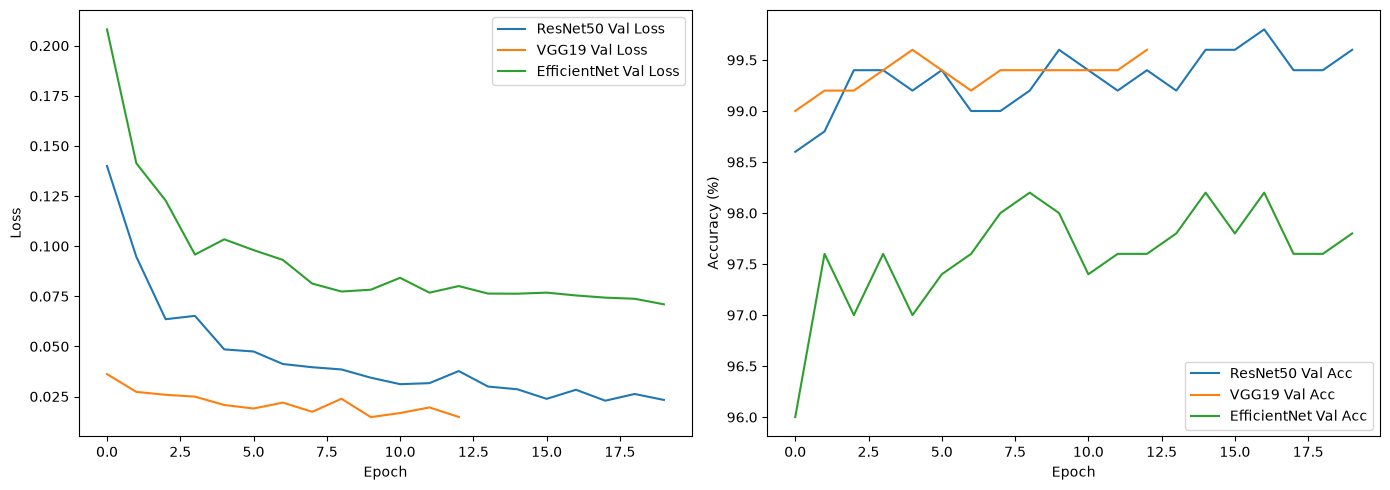

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in histories.items():
    axes[0].plot(hist["val_loss"], label=f"{name} Val Loss")
    axes[1].plot(hist["val_acc"], label=f"{name} Val Acc")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

## Nhận xét

Về độ chính xác, cả ba mô hình đều cho kết quả rất tốt trên tập kiểm thử 500 ảnh. ResNet-50 đạt kết quả cao nhất với 99.60%, bám sát ngay sau là VGG-19 với 99.40%. EfficientNet-B0 đạt 97.80%, thấp hơn một chút nhưng vẫn là mức độ chính xác cao đối với bài toán ba lớp.

EfficientNet-B0 vượt trội về thời gian suy luận chỉ khoảng 0.58 ms mỗi ảnh, nhanh hơn gấp đôi ResNet-50 (1.30 ms) và gần năm lần so với VGG-19 (2.81 ms). VGG-19 cũng mất nhiều thời gian nạp vào bộ nhớ nhất do kích thước kiến trúc.

Về quá trình huấn luyện, VGG-19 hội tụ nhanh và sớm chạm ngưỡng tối ưu, kích hoạt dừng sớm ở epoch 13. Với ResNet-50 và EfficientNet giữ được đà giảm loss đều đặn nên chạy đủ 20 epoch mà không bị ngắt giữa chừng.

Với các mô hình trước đó, chỉ số Accuracy chỉ ở 70 - 75%, do backbone khá đơn giản, và các tầng chưa đủ sâu để bắt được các đặc trưng của các đối tượng.